In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
california = fetch_california_housing(as_frame=True)
df = california.frame

# Extract feature (AveRooms) and target (MedHouseVal)
X = df[['AveRooms']].values
y = df['MedHouseVal'].values.reshape(-1, 1)

print(f"Dataset Loaded successfully.")
print(f"Feature Matrix Shape (X): {X.shape}")
print(f"Target Vector Shape (y): {y.shape}\n")

# Apply Standard Scaling
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

m = len(y)
X_b = np.c_[np.ones((m, 1)), X_scaled]

Dataset Loaded successfully.
Feature Matrix Shape (X): (20640, 1)
Target Vector Shape (y): (20640, 1)



In [5]:
print(df)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  MedHouseVal  
0      

In [4]:

theta_normal_scaled = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y_scaled)
y_pred_normal_scaled = X_b.dot(theta_normal_scaled)
y_pred_normal = scaler_y.inverse_transform(y_pred_normal_scaled)


def compute_cost(X, y, theta):
    """Compute Mean Squared Error Cost."""
    m = len(y)
    predictions = X.dot(theta)
    cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return cost

def gradient_descent(X, y, theta, learning_rate, iterations):
    """Perform batch gradient descent to learn theta."""
    m = len(y)
    cost_history = []

    for i in range(iterations):
        gradients = (1 / m) * X.T.dot(X.dot(theta) - y)
        theta = theta - learning_rate * gradients
        cost_history.append(compute_cost(X, y, theta))

    return theta, cost_history

# Initialize hyperparameters
learning_rate = 0.01
iterations = 1500
initial_theta = np.zeros((2, 1))


theta_gd_scaled, cost_history = gradient_descent(X_b, y_scaled, initial_theta, learning_rate, iterations)

y_pred_gd_scaled = X_b.dot(theta_gd_scaled)
y_pred_gd = scaler_y.inverse_transform(y_pred_gd_scaled)

In [6]:
mse_normal = mean_squared_error(y, y_pred_normal)
r2_normal = r2_score(y, y_pred_normal)

mse_gd = mean_squared_error(y, y_pred_gd)
r2_gd = r2_score(y, y_pred_gd)

print("----- MODEL EVALUATION RESULTS -----")
print(f"Normal Equation:\n  - Mean Squared Error (MSE): {mse_normal:.4f}\n  - R-squared (R²):           {r2_normal:.4f}")
print(f"Gradient Descent:\n  - Mean Squared Error (MSE): {mse_gd:.4f}\n  - R-squared (R²):           {r2_gd:.4f}\n")
print(f"Final Weights (Scaled) - Normal Equation: Intercept = {theta_normal_scaled[0][0]:.4f}, Slope = {theta_normal_scaled[1][0]:.4f}")
print(f"Final Weights (Scaled) - Gradient Descent: Intercept = {theta_gd_scaled[0][0]:.4f}, Slope = {theta_gd_scaled[1][0]:.4f}")

----- MODEL EVALUATION RESULTS -----
Normal Equation:
  - Mean Squared Error (MSE): 1.3008
  - R-squared (R²):           0.0231
Gradient Descent:
  - Mean Squared Error (MSE): 1.3008
  - R-squared (R²):           0.0231

Final Weights (Scaled) - Normal Equation: Intercept = 0.0000, Slope = 0.1519
Final Weights (Scaled) - Gradient Descent: Intercept = 0.0000, Slope = 0.1519


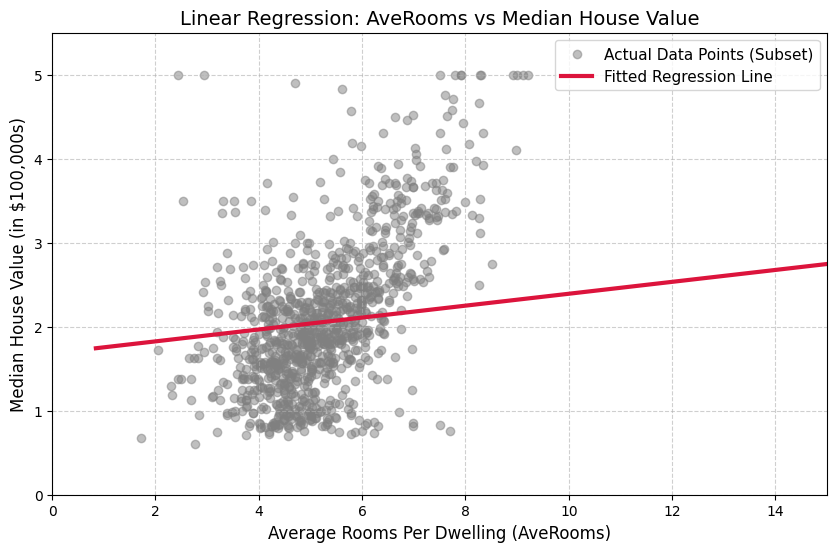

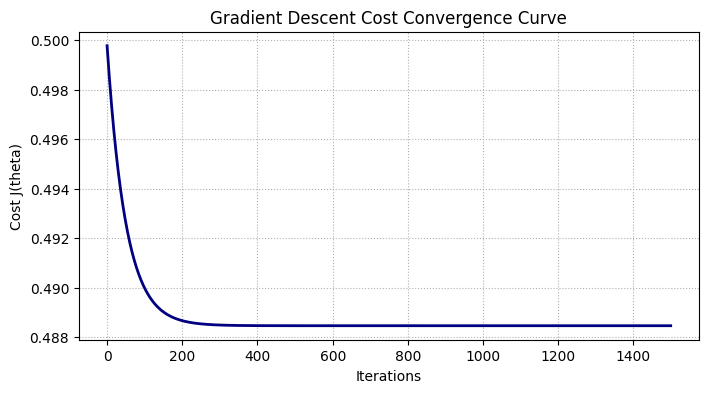

In [7]:
sort_axis = np.argsort(X.flatten())
X_sorted = X[sort_axis]
y_pred_gd_sorted = y_pred_gd[sort_axis]

plt.figure(figsize=(10, 6))
plt.scatter(X[:1000], y[:1000], color='gray', alpha=0.5, label='Actual Data Points (Subset)')
plt.plot(X_sorted, y_pred_gd_sorted, color='crimson', linewidth=3, label='Fitted Regression Line')

plt.title('Linear Regression: AveRooms vs Median House Value', fontsize=14)
plt.xlabel('Average Rooms Per Dwelling (AveRooms)', fontsize=12)
plt.ylabel('Median House Value (in $100,000s)', fontsize=12)
plt.xlim(0, 15)
plt.ylim(0, 5.5)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Plot Convergence curve history
plt.figure(figsize=(8, 4))
plt.plot(range(iterations), cost_history, color='navy', linewidth=2)
plt.title('Gradient Descent Cost Convergence Curve')
plt.xlabel('Iterations')
plt.ylabel('Cost J(theta)')
plt.grid(True, linestyle=':')
plt.show()